In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 58.7 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numb

In [2]:
import kagglehub

path = kagglehub.dataset_download("aliabdelmenam/rdd-2022")

print(path)

/kaggle/input/datasets/aliabdelmenam/rdd-2022


In [3]:
yaml_content = """
path: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT

train: train/images
val: val/images
test: test/images

names:
  0: longitudinal crack
  1: transverse crack
  2: alligator crack
  3: other corruption
  4: pothole
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created")

data.yaml created


In [4]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
model = YOLO("yolov8s.pt")

results = model.train(
    data="data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    save_period=1,
    workers=4,
    project="/kaggle/working",
    name="yolov8s_baseline"
)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspect

In [6]:
!zip -r yolov8s_baseline.zip /kaggle/working/yolov8s_baseline

  adding: kaggle/working/yolov8s_baseline/ (stored 0%)
  adding: kaggle/working/yolov8s_baseline/BoxF1_curve.png (deflated 9%)
  adding: kaggle/working/yolov8s_baseline/train_batch1.jpg (deflated 3%)
  adding: kaggle/working/yolov8s_baseline/val_batch1_pred.jpg (deflated 8%)
  adding: kaggle/working/yolov8s_baseline/val_batch2_pred.jpg (deflated 10%)
  adding: kaggle/working/yolov8s_baseline/BoxR_curve.png (deflated 8%)
  adding: kaggle/working/yolov8s_baseline/train_batch16802.jpg (deflated 6%)
  adding: kaggle/working/yolov8s_baseline/val_batch1_labels.jpg (deflated 8%)
  adding: kaggle/working/yolov8s_baseline/train_batch16800.jpg (deflated 9%)
  adding: kaggle/working/yolov8s_baseline/confusion_matrix.png (deflated 19%)
  adding: kaggle/working/yolov8s_baseline/val_batch2_labels.jpg (deflated 10%)
  adding: kaggle/working/yolov8s_baseline/results.csv (deflated 59%)
  adding: kaggle/working/yolov8s_baseline/weights/ (stored 0%)
  adding: kaggle/working/yolov8s_baseline/weights/epoch

## Results Summary

The YOLOv8s model outperformed YOLOv8n across all evaluation metrics.

Final Results:

- Precision: 0.626
- Recall: 0.553
- mAP@0.5: 0.592
- mAP@0.5:0.95: 0.317

Observations:

- YOLOv8s provided improved feature extraction capacity.
- Detection performance improved across all damage categories.
- Pothole detection remained the weakest class.
- The results establish YOLOv8s as the strongest baseline model for subsequent SAHI experiments.

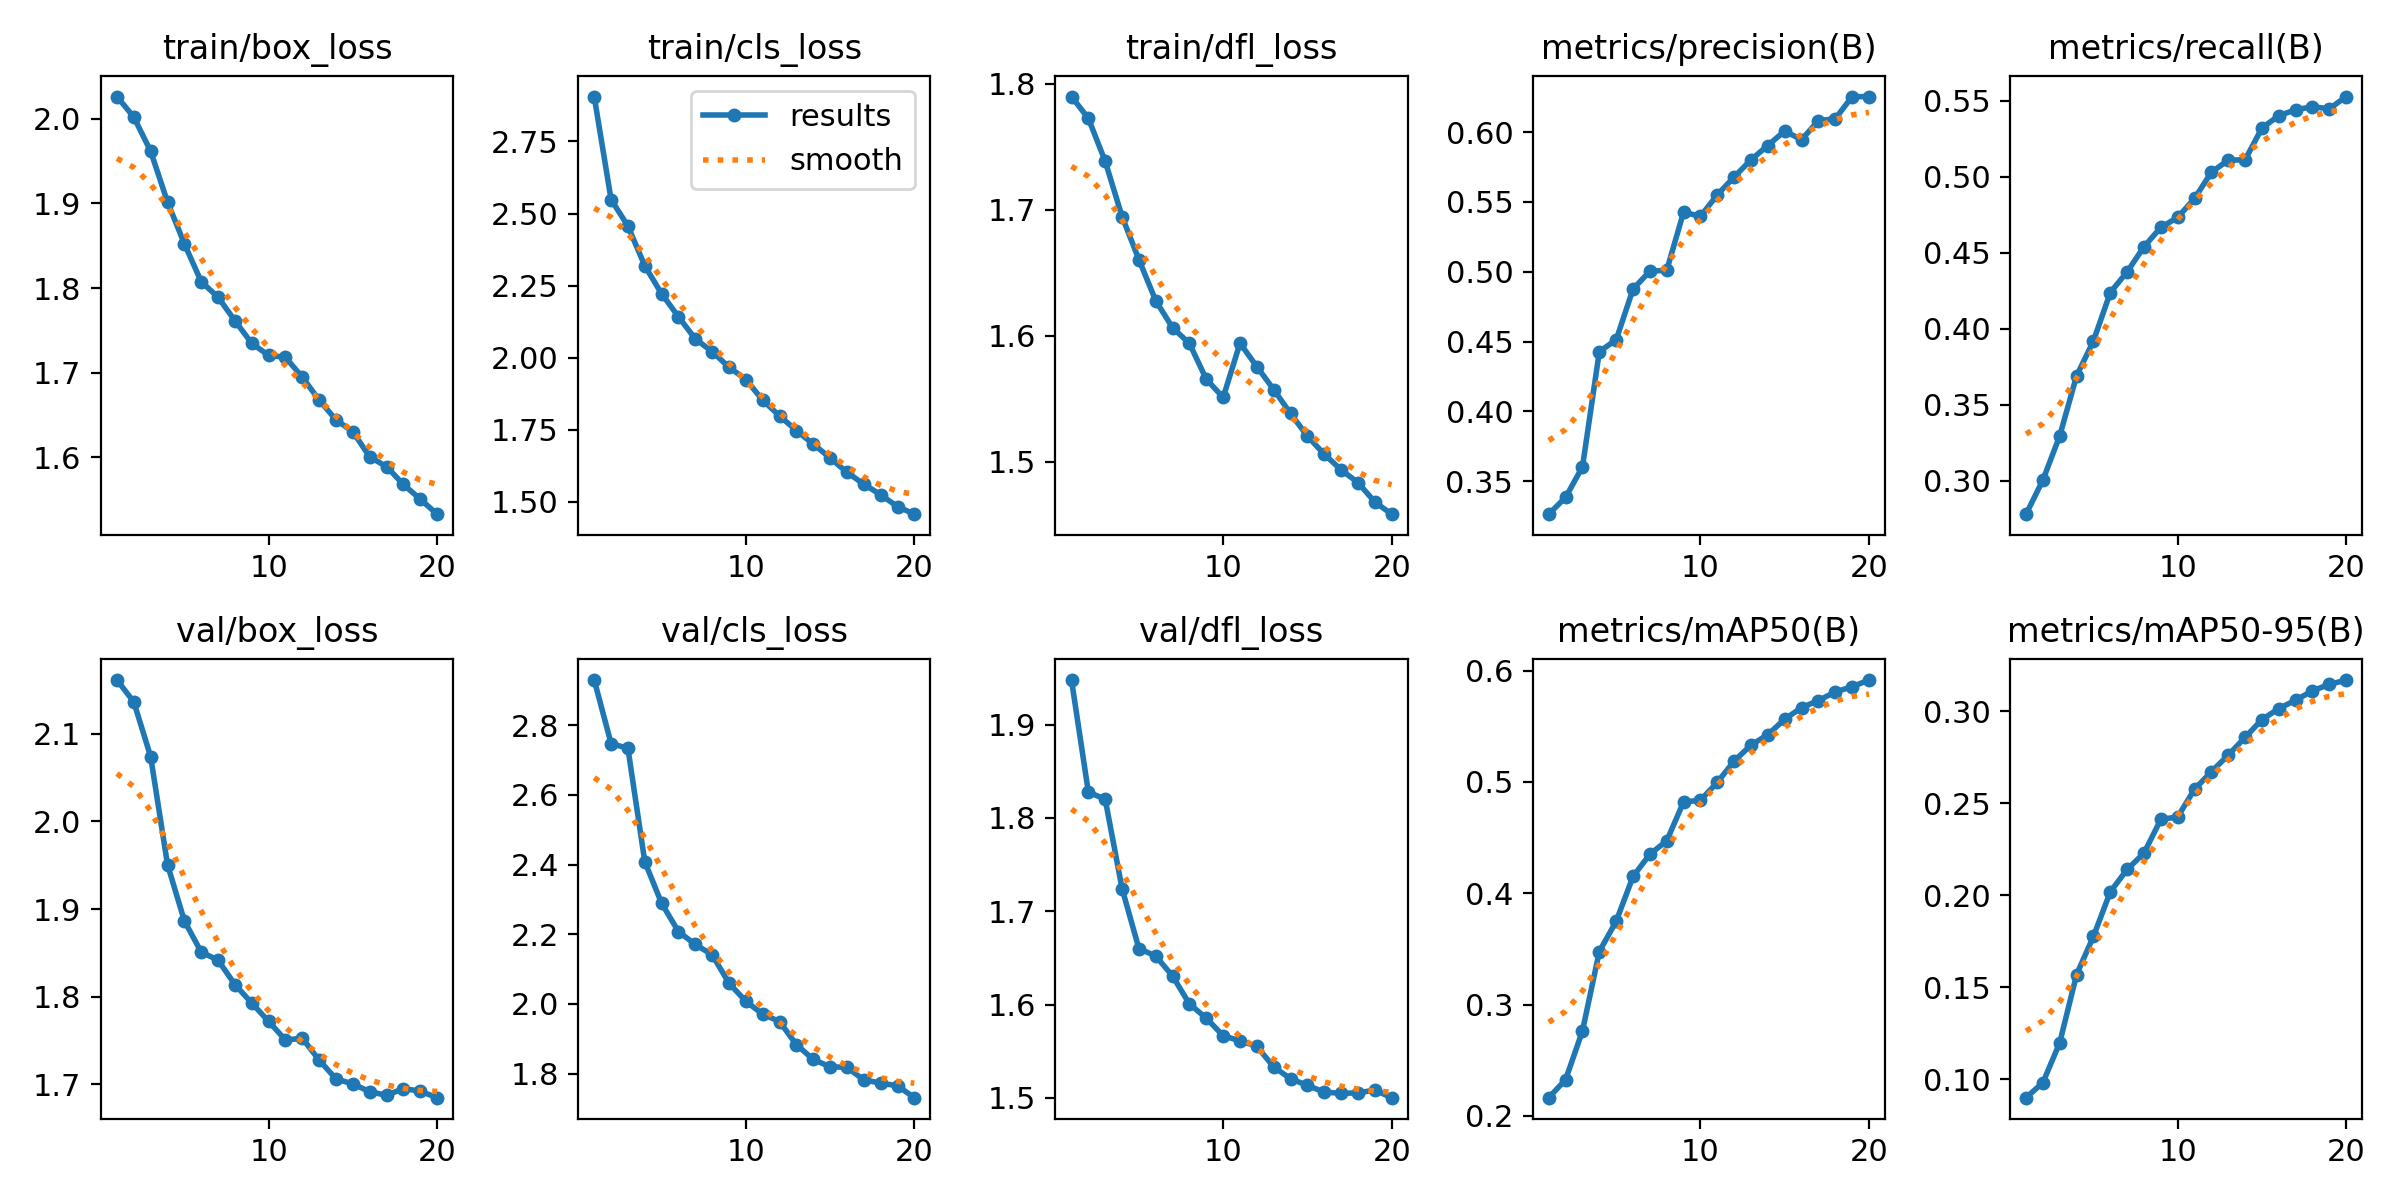

In [1]:
from IPython.display import Image

Image("../reports/results/yolov8s/results.png")

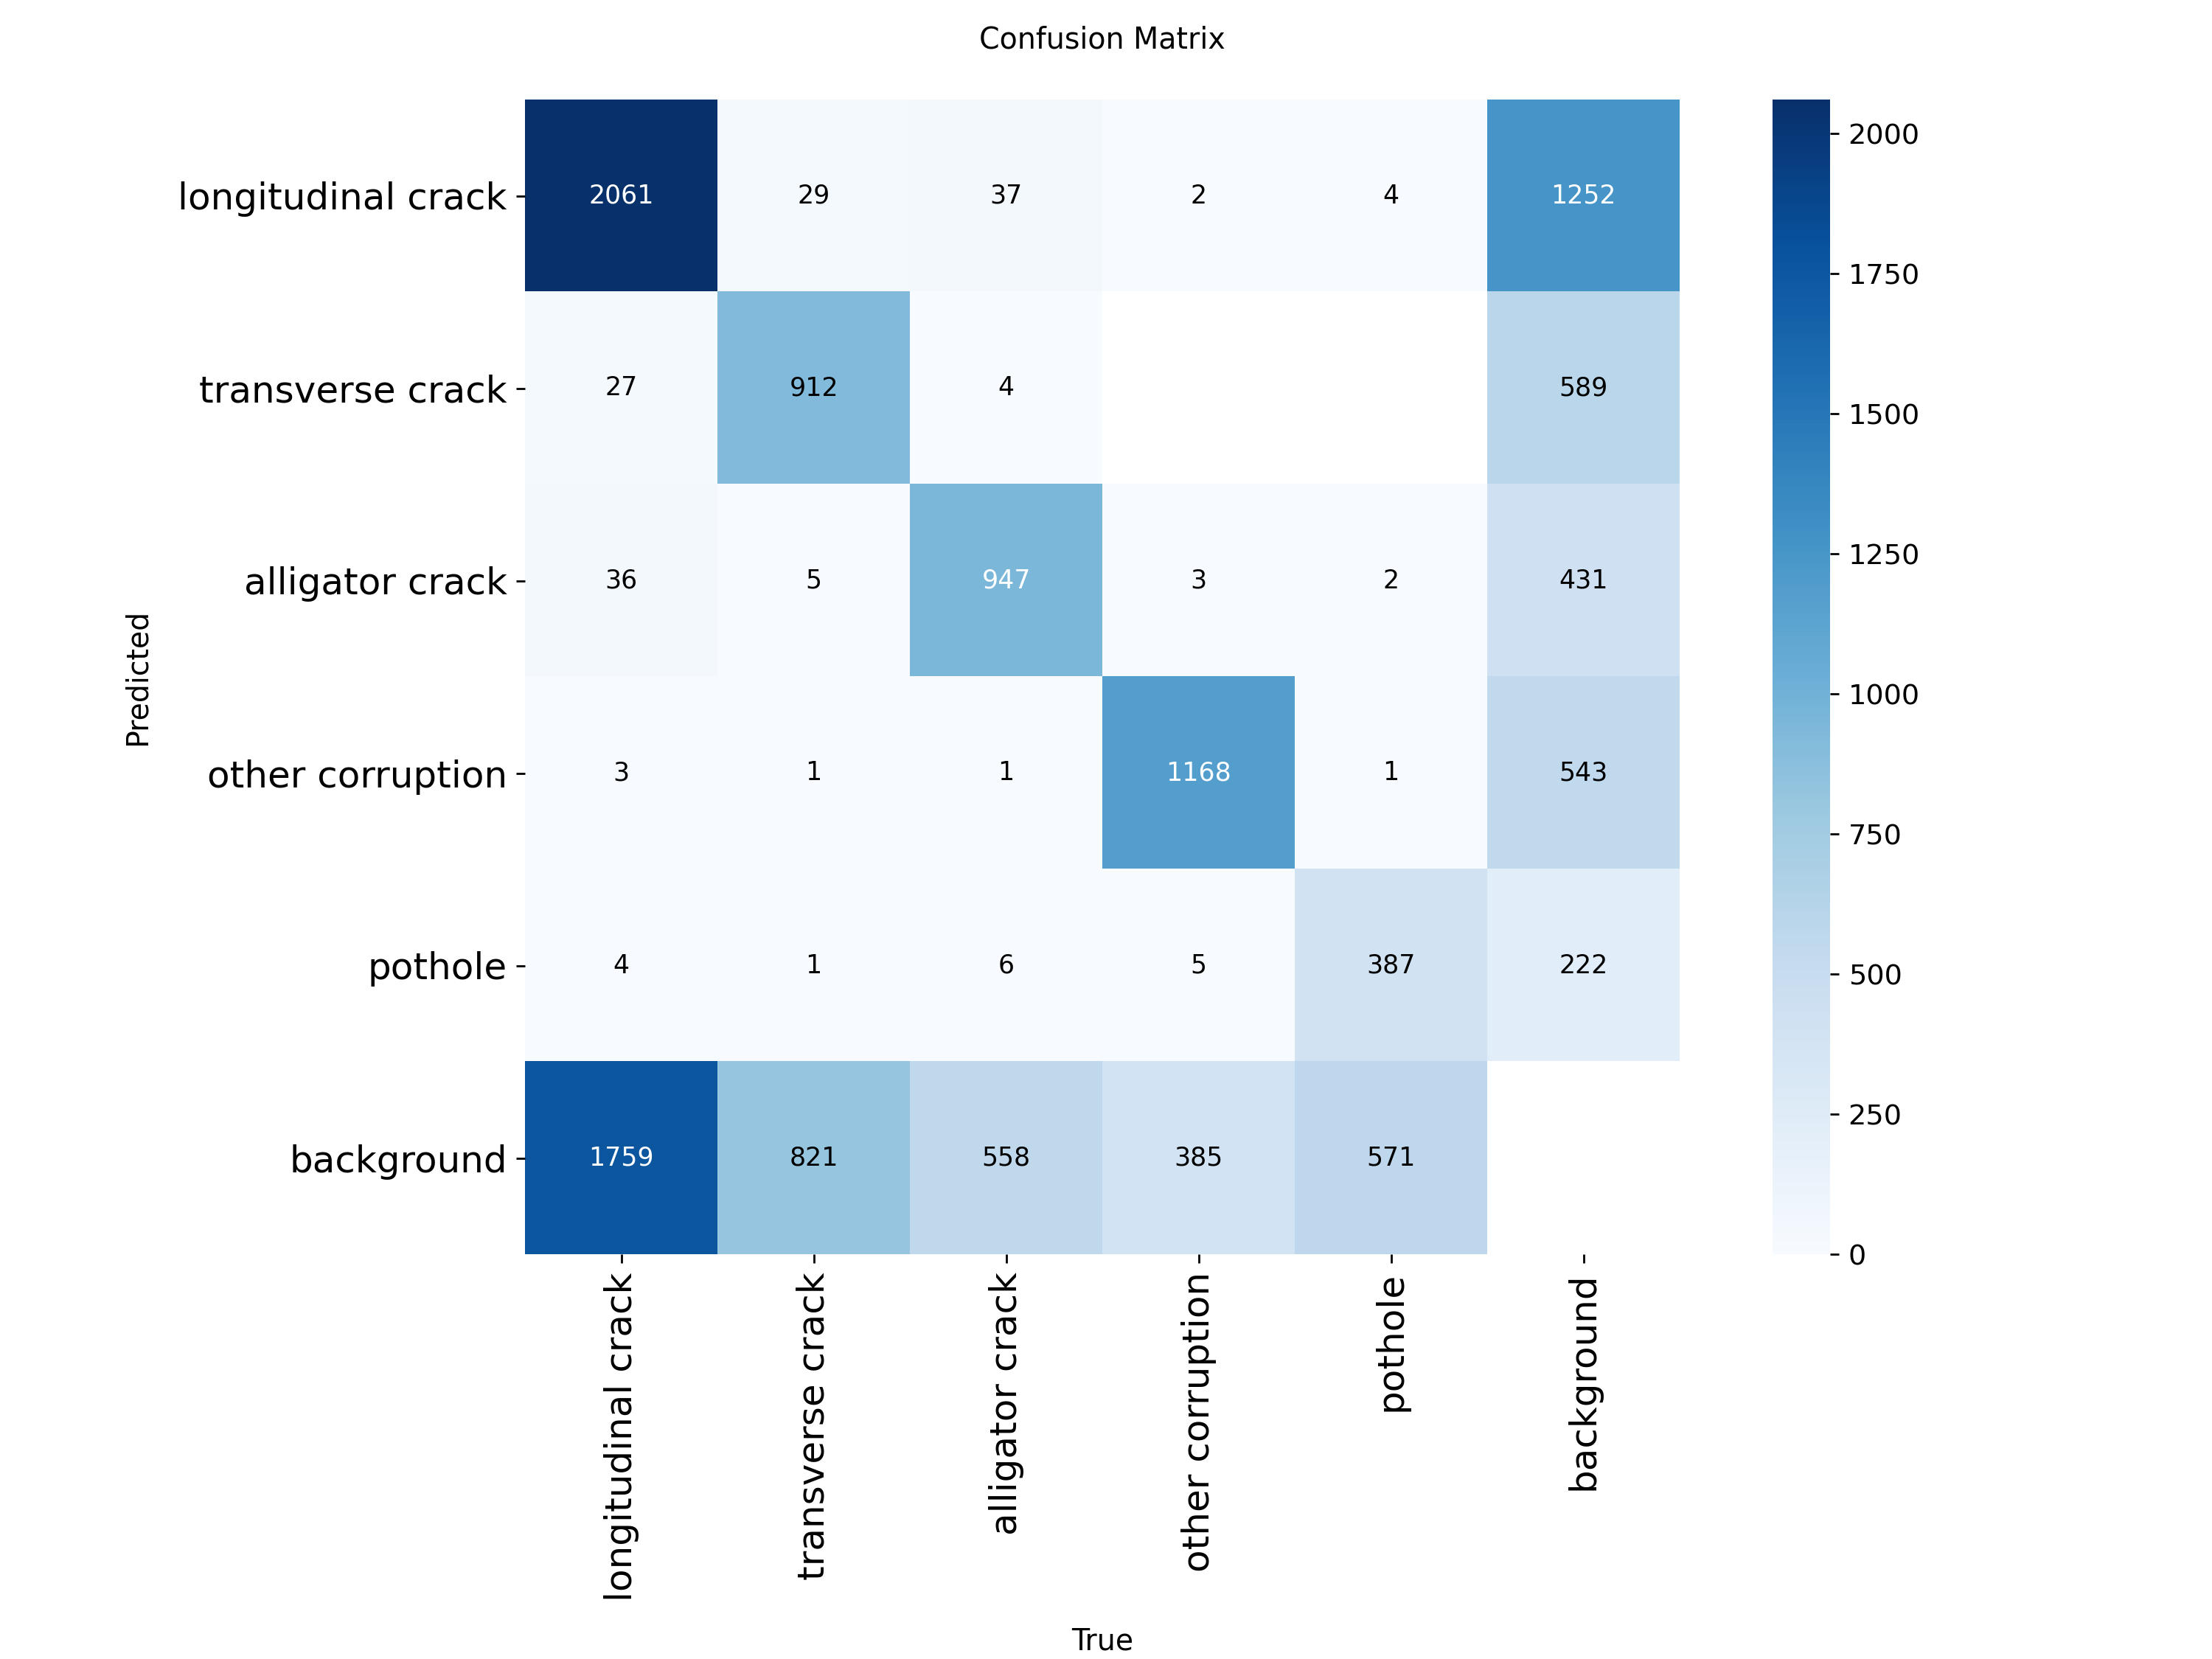

In [2]:
Image("../reports/results/yolov8s/confusion_matrix.png")